# Load Libraries

In [23]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio, rasterio.plot
from rasterio.io import MemoryFile
from rasterio.mask import mask
from rasterio.transform import from_bounds
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask
from rasterio.windows import from_bounds as window_from_bounds, transform as window_transform

# Coupled MODFLOW–SWMM: Bowers Beach walkthrough

This notebook walks a new user end-to-end through **running the coupled MODFLOW–SWMM model on the Bowers Beach, DE example** that ships with this repository.

**What this notebook covers**
- Which input files the coupling needs and where they live
- How to launch the coupled simulation from Python
- Where the outputs are saved and how to plot or analyse them

**What this notebook does *not* cover**
- Building a MODFLOW model from scratch → see the [FloPy tutorials](https://flopy.readthedocs.io/)
- Building a SWMM model from scratch → see the [SWMM user manual](https://www.epa.gov/water-research/storm-water-management-model-swmm), [pyswmm docs](https://pyswmm.github.io/pyswmm/) and [swmmio docs](https://swmmio.readthedocs.io/en/v0.8.5/)
- Benchmarking, SLR scenarios, or scientific interpretation; publication that does this is in preparation

If you want a command-line shortcut instead of a notebook, `python main.py run-simulation` from the project root does the same thing as No. 5 below. See the`README.md` for CLI flags.

## 1. Environment check

Confirm the required Python packages and the MODFLOW 6 shared library are available.

In [ ]:
import sys, platform
from pathlib import Path

import flopy, pyswmm, modflowapi

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

for name, mod in [("flopy", flopy), ("pyswmm", pyswmm), ("modflowapi", modflowapi)]:
    print(f"{name:12s} {mod.__version__}")
print(f"python       {sys.version.split()[0]}")
print(f"platform     {platform.system()} {platform.machine()}")

dll_map = {"windows": "win/libmf6.dll", "darwin": "mac/libmf6.dylib", "linux": "linux/libmf6.so"}
dll_path = project_root / "exe" / dll_map[platform.system().lower()]
assert dll_path.exists(), f"MODFLOW 6 shared library missing at {dll_path}"
print(f"MF6 library  {dll_path.relative_to(project_root)}")

flopy        3.9.4
pyswmm       2.1.1
modflowapi   0.2.0
python       3.12.3
platform     Darwin x86_64
MF6 library  exe/mac/libmf6.dylib


## 2. Required inputs

The coupled model needs five things. Every path below is a default, you can overwrite any of them when you call `run_coupled_simulation(...)`.

| Input | Why needed | Where it comes from | Default location | Used by |
|---|---|---|---|---|
| MODFLOW 6 workspace | Groundwater model — grid, boundary conditions, packages | Built with FloPy (see FloPy tutorials) | `modflow_ws/` | `CoupledSimulation.run_coupled_simulation(modflow_workspace=…)` |
| SWMM `.inp` file | Sewer / stormwater network + subcatchments | Built with SWMM GUI | `swmm_inp/Bowers_beach.inp` | `run_coupled_simulation(swmm_input_path=…)` via `pyswmm` |
| Subcatchments shapefile | Maps SWMM subcatchments to MODFLOW cells for recharge proportioning | Exported from SWMM GUI | `shp_files/delineation_shpfile.shp` | Spatial proportioning inside `CoupledSimulation.setup_simulation_data` |
| Nodes shapefile | Places SWMM junctions / outfalls in MODFLOW space for drainage routing | Exported from SWMM GUI | `shp_files/swmm_junc_out.shp` | Drainage routing + post-processing maps |
| Sanitary nodes CSV | Marks which SWMM nodes act as sanitary sewers for the well package (groundwater leakage) | **Auto-generated during setup** — `classify_swmm_objects` identifies sanitary nodes from the SWMM `.inp` (starts at the `[DWF]` section and traces downstream through the connected pipes), and the node geolocator writes them to this CSV. You do not make this file yourself. | `results/sanitary_nodes.csv` | `WellManager` inside `CoupledSimulation` |

The MODFLOW 6 shared library in `exe/` is auto-selected by OS in Section 1.

> **Note on adapting to other sites:** because sanitary nodes are picked from the `.inp` itself (not from ID prefixes like `M*`/`SO*`), the framework will work on a differently-named network as long as the `.inp` has a `[DWF]` section that seeds the sanitary sub-network.

## 3. Point at the input files

Set the paths and fail loud if anything is missing.

In [ ]:
modflow_ws   = project_root / "modflow_ws"
swmm_inp     = project_root / "swmm_inp" / "Bowers_beach.inp"
subcatch_shp = project_root / "shp_files" / "delineation_shpfile.shp"
nodes_shp    = project_root / "shp_files" / "swmm_junc_out.shp"
well_csv     = project_root / "results" / "sanitary_nodes.csv"

for p in [modflow_ws, swmm_inp, subcatch_shp, nodes_shp, well_csv]:
    assert p.exists(), f"Missing input: {p}"
print("All inputs found.")

All inputs found.


## 4. Peek at the inputs

A quick map of the SWMM subcatchments and node locations — this is what the coupling sees before it starts.

/var/folders/8s/mgzsvsbj0q986y_46zfpw53w0000gn/T/ipykernel_96053/627755088.py:9: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left")


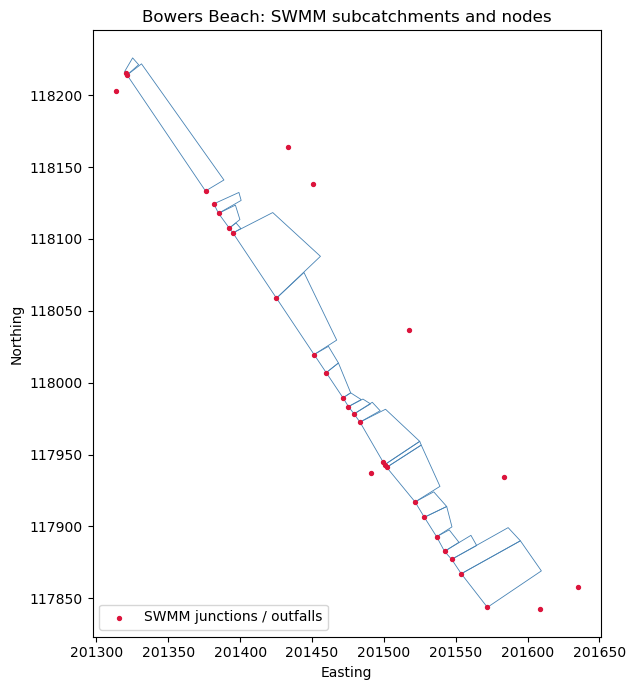

In [ ]:
subs  = gpd.read_file(subcatch_shp)
nodes = gpd.read_file(nodes_shp)

fig, ax = plt.subplots(figsize=(8, 7))
subs.plot(ax=ax, facecolor="none", edgecolor="steelblue", lw=0.6, label="SWMM subcatchments")
nodes.plot(ax=ax, color="crimson", markersize=8, label="SWMM junctions / outfalls")
ax.set_title("Bowers Beach: SWMM subcatchments and nodes")
ax.set_xlabel("Easting"); ax.set_ylabel("Northing")
ax.legend(loc="lower left",)
ax.set_aspect("equal")
plt.tight_layout()

## 5. Run the coupled simulation

One call. `CoupledSimulation.run_coupled_simulation` handles the standalone MODFLOW load, the SWMM ↔ MODFLOW spatial mapping, the callback-driven data exchange at every stress period, and finalization of the SWMM report.

`scenario="baseline"` tags every output file with a `_baseline` suffix so a later SLR run doesn't overwrite it. This is the long-running step — expect it to take a while on the full Bowers Beach case.

In [ ]:
import logging
sys.path.insert(0, str(project_root))
from src.coupled_simulation import CoupledSimulation

coupled_sim = CoupledSimulation(
    model_name="Bowers_beach",
    log_level=logging.INFO,
    scenario="baseline",
)

results = coupled_sim.run_coupled_simulation(
    modflow_workspace       = str(modflow_ws),
    swmm_input_path         = str(swmm_inp),
    subcatchments_shapefile = str(subcatch_shp),
    nodes_shapefile         = str(nodes_shp),
    dll_path                = str(dll_path),
    sim_ws                  = str(modflow_ws),
    well_csv_path           = str(well_csv),
    validate_first          = True,
)
print("Coupled run finished.")

INFO:src.coupled_simulation:Validating setup before simulation...
INFO:src.coupled_simulation:============================================================
MODFLOW-SWMM COUPLING VALIDATION REPORT

1. PROPORTIONING MATRIX VALIDATION
----------------------------------------
Total records: 78
Unique subcatchments: 21
Unique cells: 39

MODFLOW proportions:
  Min: 0.000002
  Max: 0.920530
  Mean: 0.164254
  Sum: 12.811812

SWMM proportions:
  Min: 0.000002
  Max: 1.000000
  Mean: 0.269239
  Sum: 21.000604

2. NODE MAPPING VALIDATION
----------------------------------------
Cells with nodes: 20
Total nodes mapped: 32

Nodes per cell distribution:
  1 nodes: 13 cells
  2 nodes: 3 cells
  3 nodes: 3 cells
  4 nodes: 1 cells

3. SWMM MODEL VALIDATION
----------------------------------------
Total nodes: 32
Total subcatchments: 21
Sanitary nodes: 6
Sanitary node IDs: ['M1', 'M2', 'M3', 'M4', 'M5', 'SO1']

5. WARNINGS
----------------------------------------
No warnings found.




Valid nodes within grid bounds: 32

Mapping Summary:
  Total nodes processed: 32
  Valid nodes mapped: 32
  MODFLOW cells with nodes: 20
  Total node-cell mappings: 32

Exported 6 sanitary nodes to 'results/sanitary_nodes.csv'.


INFO:src.coupled_simulation:  Loaded well package data: 6 wells
INFO:src.coupled_simulation:Setting up SWMM simulation...
INFO:src.coupled_simulation:Simulation data setup completed successfully!
INFO:src.coupled_simulation:Starting coupled simulation...
INFO:src.coupled_simulation:  Calling modflowapi.run_simulation...
INFO:src.coupled_simulation:=== MODFLOW-SWMM Coupling Initialization ===
INFO:src.coupled_simulation:=== MODFLOW-SWMM Coupling Initialized ===
INFO:src.coupled_simulation:ApiSimulation model names found: ['bowers_beach']
INFO:src.coupled_simulation:  Model: BOWERS_BEACH, Grid: 260x323, Stress Periods: 365
INFO:src.coupled_simulation:  Recharge will be read when needed (API may not be initialized yet)
INFO:src.coupled_simulation:  Cell sizes: delr=27.00, delc=27.00, area=729.00 m2
INFO:src.coupled_simulation:  Conductances: positive=8.64e-02, negative=0.00e+00 m2/day
ERROR:src.coupled_simulation:  Original_recharge is None after initialization!
INFO:src.coupled_simulatio

NORMAL TERMINATION OF SIMULATION
Coupled run finished.


## 6. Generate post-run outputs

`generate_outputs` writes the standard set of post-simulation outputs into `results/simulation/` — head differences, subcatchment groundwater state, mean groundwater depth map, and the mean water-table GeoTIFF. All filenames are suffixed with the scenario tag from Section 5.

In [15]:
from src.postprocess import generate_outputs

generate_outputs(coupled_sim)

INFO:src.coupled_simulation:Exporting groundwater-invert head differences...
INFO:src.coupled_simulation:Exported 1510 head difference records to results/simulation/gw_head_differences_baseline.csv
INFO:src.coupled_simulation:Exporting subcatchment gw_state time series...
INFO:src.coupled_simulation:Saved max_infil_volume CSV → results/simulation/subcatchment_max_infil_vol_baseline.csv
INFO:src.coupled_simulation:Saved gwt_elev CSV → results/simulation/subcatchment_gwt_elev_ft_baseline.csv
INFO:src.coupled_simulation:Generating mean groundwater depth map...
INFO:src.coupled_simulation:Saved mean groundwater depth map to results/simulation/mean_groundwater_depth_map_baseline.png
INFO:src.coupled_simulation:Exporting mean water table to .tif file...
INFO:src.coupled_simulation:Successfully exported mean water table to results/simulation/mean_water_table_baseline.tif


## 7. Focus on the coupled area

The saved PNG in Section 6 covers the whole MODFLOW domain and stretches the colormap across the *entire* grid. Here we re-plot the same mean-groundwater-depth field but restricted to the coupled sub-network:

1. **Clip the raster to `shp_files/zone_bud_shp.shp`** using `rasterio.mask.mask()`. This is the polygon that covers the whole coupled sub-network (not just the SWMM subcatchments).
2. **Scale the colorbar to the min/max of depth inside that AOI**, so the color range reflects the coupled area rather than the wider domain.
3. **Overlay the SWMM network** — subcatchment boundaries (white), conduits (yellow) from `Bowers_beach_conduits.shp`, and all nodes (crimson) from `swmm_junc_out.shp`.
4. **Aerial basemap** (Esri World Imagery, via `contextily`) fills the rest of the view.

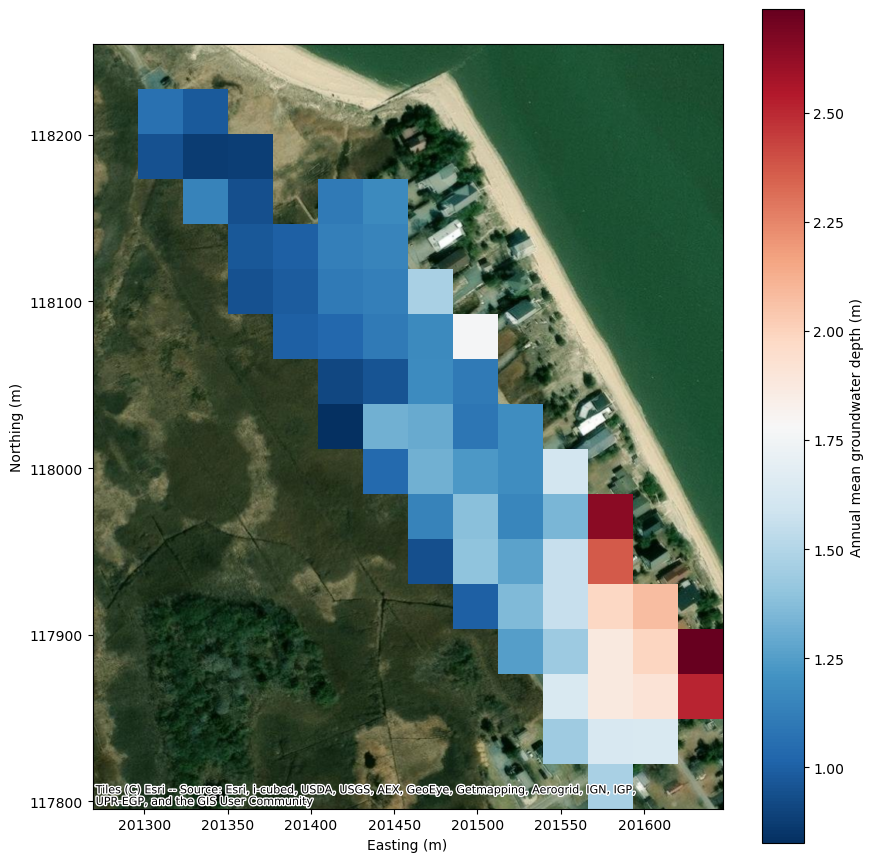

In [24]:
if coupled_sim.data.head_count == 0:
    print("No head data captured - did section 5 finish?")
else:
    
    mean_head = coupled_sim.data.head_sum / coupled_sim.data.head_count
    mean_depth = np.where(mean_head > -1e10, coupled_sim.data.grid_top - mean_head, np.nan)

    mg = coupled_sim.data.gwf.modelgrid
    depth = mean_depth.reshape(mg.nrow, mg.ncol).astype("float64")

    xmin, xmax, ymin, ymax = mg.extent
    transform = from_bounds(xmin, ymin, xmax, ymax, mg.ncol, mg.nrow)

    aoi_shp = project_root / "shp_files" / "zone_bud_shp.shp"
    aoi = gpd.read_file(aoi_shp)

    # Keep AOI and model grid in the same CRS before masking/cropping.
    model_crs = getattr(mg, "crs", None)
    if model_crs is not None and aoi.crs is not None and str(aoi.crs) != str(model_crs):
        aoi = aoi.to_crs(model_crs)

    # Mask to AOI footprint.
    in_aoi = geometry_mask(
        aoi.geometry,
        out_shape=depth.shape,
        transform=transform,
        invert=True,
    )
    depth_masked = np.where(in_aoi, depth, np.nan)

    # Crop to AOI bounding box so extent is not the full MODFLOW domain.
    xmin_aoi, ymin_aoi, xmax_aoi, ymax_aoi = aoi.total_bounds
    window = window_from_bounds(xmin_aoi, ymin_aoi, xmax_aoi, ymax_aoi, transform=transform)
    window = window.round_offsets().round_lengths()

    r0 = max(0, int(window.row_off))
    c0 = max(0, int(window.col_off))
    r1 = min(depth_masked.shape[0], r0 + int(window.height))
    c1 = min(depth_masked.shape[1], c0 + int(window.width))

    depth_clipped = depth_masked[r0:r1, c0:c1]
    clipped_transform = window_transform(window, transform)
    extent_clipped = rasterio.plot.plotting_extent(depth_clipped, clipped_transform)

    valid = depth_clipped[~np.isnan(depth_clipped)]
    if valid.size == 0:
        raise ValueError("AOI clip produced no valid groundwater-depth cells.")
    vmin, vmax = float(valid.min()), float(valid.max())

    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad(alpha=0)  # transparent NaN so the basemap shows through

    fig, ax = plt.subplots(figsize=(9, 9))

    im = ax.imshow(
        depth_clipped,
        cmap=cmap,
        extent=extent_clipped,
        origin="upper",
        vmin=vmin,
        vmax=vmax,
        zorder=2,
    )

    ax.set_xlim(extent_clipped[0], extent_clipped[1])
    ax.set_ylim(extent_clipped[2], extent_clipped[3])
    ax.set_aspect("equal")

    # Aerial basemap for context (needs internet).
    try:
        import contextily as cx

        basemap_crs = aoi.crs if aoi.crs is not None else model_crs
        cx.add_basemap(
            ax,
            crs=basemap_crs,
            source=cx.providers.Esri.WorldImagery,
            zorder=1,
        )
    except Exception as e:
        print(f"Basemap skipped: {e}")

    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(useOffset=False, style="plain")
    plt.colorbar(im, ax=ax, label="Annual mean groundwater depth (m)")
    plt.tight_layout()

## 8. Where outputs are saved

All post-run artifacts land in `results/simulation/` with the scenario tag appended to the filename (e.g. `mean_water_table_baseline.tif`).

| Output | File | Written by |
|---|---|---|
| Full simulation log | `logs/simulation.log` | logging in `main.py` / `src/coupled_simulation.py` |
| GW-invert head differences | `results/simulation/gw_head_differences_<scenario>.csv` | `WellManager.export_head_differences_to_csv` |
| Subcatchment GW-state time series | `results/simulation/*_<scenario>.csv` | `SwmmRunManager.save_subcatchment_gw_state_csvs` |
| Mean groundwater depth (PNG) | `results/simulation/mean_groundwater_depth_map_<scenario>.png` | `postprocess.plot_mean_groundwater_depth` |
| Mean water table (GeoTIFF) | `results/simulation/mean_water_table_<scenario>.tif` | `postprocess.export_mean_head_to_tif` |

## 9. Where to go next

- **Run without a notebook**: `python main.py run-simulation`, see the `README.md` for all CLI flags
- **Build your own MODFLOW model**: [FloPy tutorials](https://flopy.readthedocs.io/)
- **Build your own SWMM model**: [EPA SWMM manual](https://www.epa.gov/water-research/storm-water-management-model-swmm) + [pyswmm docs](https://pyswmm.readthedocs.io/) + [swmmio](https://swmmio.readthedocs.io/en/v0.8.5/)
<!-- - **Scientific results, benchmarking, and SLR scenarios**: the manuscript and figures in `paper_figures/` — deliberately out of scope here. -->